# Spatial Embedding: Initial Investigation

Phase 1 pipeline through Stage 2: chaos JSON → co-occurrence matrix → PPMI → truncated SVD embedding.
Includes EDA, symmetry / sparsity checks, singular value spectrum, and nearest-neighbor sanity check.

Data: `gen9championsvgc2026regma-1500.json` (VGC Reg M-A Champions, 1500 cutoff, 3.1M battles, 263 Pokémon).
See `vgc_complexity_phase1_plan.md` for methodology.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

import helpers

DATA_PATH = "gen9championsvgc2026regma-1500.json"
RNG_SEED = 0

## Load chaos data

In [2]:
chaos = helpers.load_chaos(DATA_PATH)
print(f"metagame:  {chaos.metagame}")
print(f"cutoff:    {chaos.cutoff}")
print(f"battles:   {chaos.n_battles:,}")
print(f"pokemon:   {len(chaos.pokemon)}")

metagame:  gen9championsvgc2026regma
cutoff:    1500
battles:   3,122,222
pokemon:   263


## Usage distribution

Expect an approximate Zipfian / power-law tail. Plot log-rank vs log-usage.

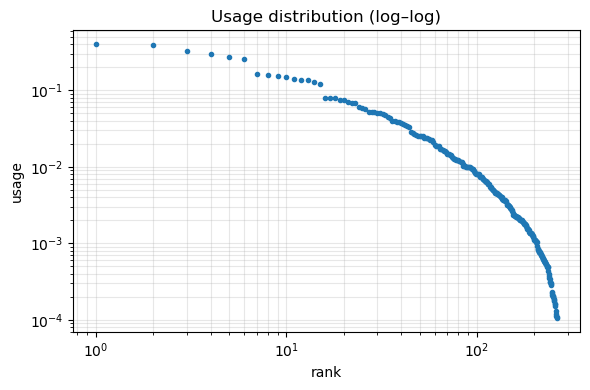

In [3]:
usages = sorted((e["usage"] for e in chaos.pokemon.values()), reverse=True)
ranks = np.arange(1, len(usages) + 1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(ranks, usages, marker=".", linestyle="none")
ax.set(xlabel="rank", ylabel="usage", title="Usage distribution (log–log)")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## Threshold sensitivity

How many Pokémon survive various usage cutoffs. The plan suggests top 100–150; we'll start broader since PPMI handles the tail and we can always tighten later.

In [4]:
for thr in (0.0, 0.005, 0.01, 0.02, 0.03, 0.05):
    vocab = helpers.build_vocab(chaos, min_usage=thr)
    print(f"usage >= {thr:>5}: {len(vocab):3d} pokemon")

usage >=   0.0: 263 pokemon
usage >= 0.005: 120 pokemon
usage >=  0.01:  88 pokemon
usage >=  0.02:  59 pokemon
usage >=  0.03:  44 pokemon
usage >=  0.05:  30 pokemon


## Build vocabulary and co-occurrence matrix

Start with `min_usage=0` (all 263 mons in `data`). PPMI's max-with-zero handles long-tail noise.
Sanity-check that the source matrix is exactly symmetric and zero-diagonal as advertised.

In [28]:
vocab = helpers.build_vocab(chaos, min_usage=0.01)
C = helpers.build_cooccurrence(chaos, vocab)

print(f"shape:         {C.shape}")
print(f"dtype:         {C.dtype}")
print(f"symmetric:     {np.allclose(C, C.T)}")
print(f"diagonal max:  {np.diag(C).max()}")
print(f"min / max:     {C.min():.2f} / {C.max():,.2f}")
print(f"nonzero frac:  {(C > 0).mean():.3f}")

shape:         (88, 88)
dtype:         float64
symmetric:     True
diagonal max:  0.0
min / max:     0.00 / 492,352.95
nonzero frac:  0.986


## PPMI

Vanilla shifted PPMI with shift=1 (i.e. unshifted). Plan calls for sweeping shift ∈ {1, 2, 5} later.

In [29]:
P = helpers.build_ppmi(C, shift=1.0)

print(f"shape:         {P.shape}")
print(f"nonzero frac:  {(P > 0).mean():.3f}")
print(f"max PPMI:      {P.max():.3f}")
print(f"mean (>0):     {P[P > 0].mean():.3f}")

shape:         (88, 88)
nonzero frac:  0.400
max PPMI:      3.186
mean (>0):     0.530


### Top-PPMI pairs

Sanity check: highest-PPMI pairs should be Pokémon that strongly cluster together (designated partners / archetype cores).

In [30]:
iu, ju = np.triu_indices_from(P, k=1)
vals = P[iu, ju]
order = np.argsort(-vals)[:25]

for k in order:
    i, j = iu[k], ju[k]
    print(f"{P[i, j]:6.3f}  {vocab[i]:30s}  {vocab[j]}")

print()
for query in ["Froslass-Mega", "Charizard-Mega-X", "Farigiraf", "Sinistcha", "Aerodactyl", "Hydreigon"]:
    print(f"{query}")
    i = vocab.index(query)
    order = np.argsort(-P[i])
    for j in order[:10]:
        print(f"  {P[i, j]:.3f}  {vocab[j]}")

 3.186  Rotom-Frost                     Empoleon
 2.804  Orthworm                        Rotom-Frost
 2.776  Typhlosion-Hisui                Tauros-Paldea-Aqua
 2.714  Oranguru                        Camerupt-Mega
 2.553  Torkoal                         Golurk-Mega
 2.547  Froslass-Mega                   Rotom-Frost
 2.461  Hatterene                       Camerupt-Mega
 2.385  Golurk-Mega                     Oranguru
 2.378  Kangaskhan-Mega                 Tauros-Paldea-Aqua
 2.369  Crabominable-Mega               Hatterene
 2.346  Tyranitar-Mega                  Excadrill
 2.308  Torkoal                         Hatterene
 2.245  Oranguru                        Drampa-Mega
 2.224  Oranguru                        Hatterene
 2.215  Crabominable-Mega               Camerupt-Mega
 2.196  Torkoal                         Oranguru
 2.159  Golurk-Mega                     Hatterene
 2.137  Gyarados-Mega                   Raichu
 2.097  Hydreigon                       Mimikyu
 2.060  Crabominable

## Singular value spectrum

Fit truncated SVD at a generous k and look for an elbow in the singular values. Plan suggests d ∈ {10, 20, 30, 50}; the elbow narrows the search.

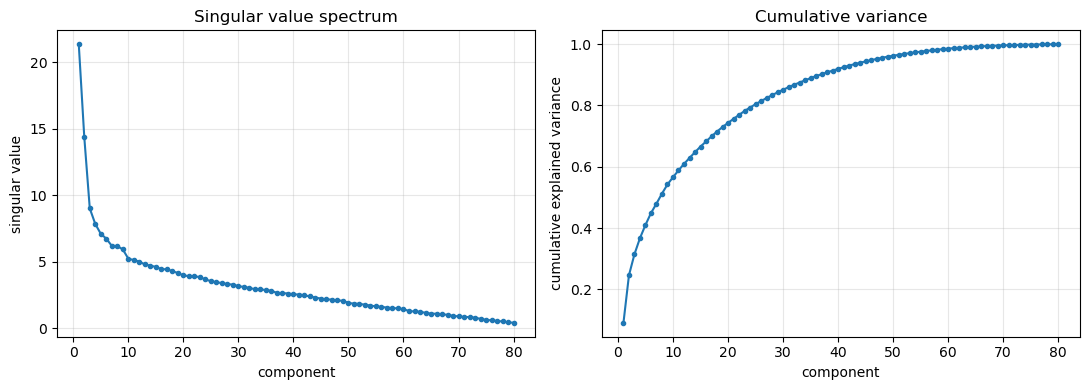

In [31]:
k_spectrum = 80
svd_full = TruncatedSVD(n_components=k_spectrum, random_state=RNG_SEED)
svd_full.fit(P)
sigma = svd_full.singular_values_

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, k_spectrum + 1), sigma, marker=".")
axes[0].set(xlabel="component", ylabel="singular value", title="Singular value spectrum")
axes[0].grid(alpha=0.3)

explained = np.cumsum(svd_full.explained_variance_ratio_)
axes[1].plot(np.arange(1, k_spectrum + 1), explained, marker=".")
axes[1].set(xlabel="component", ylabel="cumulative explained variance", title="Cumulative variance")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Spatial embedding at d=20

Start with d=20. Use `U * sqrt(Σ)` form and L2-normalize rows for cosine similarity. Plan suggests trying `U` alone too — swap later if NN rankings look off.

In [39]:
d = 12
svd = TruncatedSVD(n_components=d, random_state=RNG_SEED)
U_sigma = svd.fit_transform(P)              # rows = U[i] * sigma_i
embed = U_sigma / np.sqrt(svd.singular_values_)   # rows = U[i] * sqrt(sigma_i)

norms = np.linalg.norm(embed, axis=1, keepdims=True)
embed = embed / np.where(norms > 0, norms, 1.0)

print(f"embed shape:    {embed.shape}")
print(f"row-norm range: {np.linalg.norm(embed, axis=1).min():.3f} – {np.linalg.norm(embed, axis=1).max():.3f}")

embed shape:    (88, 12)
row-norm range: 1.000 – 1.000


## Nearest-neighbor sanity check

For well-understood Pokémon, top neighbors should be functional substitutes (similar role / archetype). If Amoonguss's neighbors are other redirection / spore users, the embedding is doing something real.

In [40]:
sim = embed @ embed.T
name_to_idx = {n: i for i, n in enumerate(vocab)}

def neighbors(name: str, k: int = 8) -> None:
    if name not in name_to_idx:
        print(f"  ({name} not in vocab)")
        return
    i = name_to_idx[name]
    order = np.argsort(-sim[i])
    order = [j for j in order if j != i][:k]
    print(f"{name}")
    for j in order:
        print(f"  {sim[i, j]:.3f}  {vocab[j]}")

for query in ["Froslass-Mega", "Charizard-Mega-X", "Farigiraf", "Sinistcha", "Aerodactyl", "Hydreigon"]:
    neighbors(query)
    print()

Froslass-Mega
  0.834  Rotom-Frost
  0.766  Garchomp
  0.691  Empoleon
  0.687  Orthworm
  0.663  Incineroar
  0.524  Arcanine-Hisui
  0.505  Kingambit
  0.480  Sneasler

Charizard-Mega-X
  0.767  Venusaur-Mega
  0.716  Kommo-o
  0.713  Tyranitar-Mega
  0.710  Gengar-Mega
  0.709  Garchomp-Mega
  0.683  Excadrill
  0.603  Skarmory-Mega
  0.591  Corviknight

Farigiraf
  0.949  Oranguru
  0.840  Hatterene
  0.827  Mimikyu
  0.713  Kangaskhan
  0.650  Venusaur
  0.608  Torkoal
  0.539  Meowstic
  0.494  Drampa-Mega

Sinistcha
  0.688  Tyranitar
  0.667  Pelipper
  0.652  Sableye
  0.643  Primarina
  0.602  Politoed
  0.526  Rotom-Heat
  0.521  Mimikyu
  0.520  Heliolisk

Aerodactyl
  0.860  Typhlosion-Hisui
  0.814  Kangaskhan-Mega
  0.776  Whimsicott
  0.767  Tauros-Paldea-Aqua
  0.715  Charizard-Mega-Y
  0.694  Meganium-Mega
  0.689  Aegislash
  0.532  Milotic

Hydreigon
  0.715  Dragapult
  0.690  Rotom-Wash
  0.675  Milotic
  0.631  Kommo-o
  0.566  Meowscarada
  0.561  Gyarados
  0.5

## Global top-20 nearest-neighbor pairs

The 20 highest cosine-similarity pairs in the embedding, independent of any query. Shows what the geometry considers globally most-similar — useful for diagnosing whether it's dominated by archetype cores, role pairs, mega/base linkages, or something else.

In [41]:
iu, ju = np.triu_indices_from(sim, k=1)
order = np.argsort(-sim[iu, ju])[:20]

for k in order:
    i, j = iu[k], ju[k]
    print(f"{sim[i, j]:.3f}  {vocab[i]:30s}  {vocab[j]}")

0.961  Gallade                         Conkeldurr
0.949  Farigiraf                       Oranguru
0.929  Orthworm                        Empoleon
0.922  Corviknight                     Excadrill
0.918  Tyranitar-Mega                  Excadrill
0.908  Golurk-Mega                     Camerupt-Mega
0.905  Pelipper                        Archaludon
0.903  Arcanine-Hisui                  Mamoswine
0.903  Pelipper                        Politoed
0.894  Oranguru                        Mimikyu
0.886  Crabominable-Mega               Golurk-Mega
0.884  Talonflame                      Maushold
0.884  Basculegion                     Pelipper
0.882  Dragonite-Mega                  Sableye
0.881  Tyranitar-Mega                  Corviknight
0.879  Dragonite-Mega                  Politoed
0.872  Drampa-Mega                     Camerupt-Mega
0.870  Dragapult                       Meowscarada
0.868  Sneasler                        Kingambit
0.868  Dragapult                       Zoroark-Hisui


## Role-residual ranking

Cosine similarity surfaces pairs with overlapping teammate distributions — both "same team" pairs (high direct PPMI) and "same slot, different teams" pairs (low direct PPMI). To isolate the latter, rank by `sim - λ · normalized(PPMI)`. The subtraction penalizes pairs that *directly* co-occur, leaving pairs whose similarity comes from sharing the same *kinds* of teammates without sharing the actual teams.

- λ=0 reduces to the previous ranking.
- λ≈0.5 strongly suppresses archetype-core pairs while keeping a few in view.
- λ=1.0 nearly eliminates them; what remains is mostly pure role substitutes (including mega/base pairs like Excadrill/Excadrill-Mega, which are substitutes by construction).

In [42]:
lam = 1.0

P_norm = P / P.max()
role_score = sim - lam * P_norm
np.fill_diagonal(role_score, -np.inf)

iu, ju = np.triu_indices_from(role_score, k=1)
order = np.argsort(-role_score[iu, ju])[:20]

print(f"lambda = {lam}")
print(f"{'rank':>4}  {'score':>6}  {'sim':>5}  {'PPMI':>5}  pair")
for r, k in enumerate(order, 1):
    i, j = iu[k], ju[k]
    print(f"{r:>4}  {role_score[i,j]:6.3f}  {sim[i,j]:5.3f}  {P[i,j]:5.2f}  {vocab[i]:25s}  {vocab[j]}")

for query in ["Froslass-Mega", "Charizard-Mega-X", "Farigiraf", "Sinistcha", "Aerodactyl", "Hydreigon", "Sableye"]:
    print(f"{query}")
    i = vocab.index(query)
    order = np.argsort(-role_score[i])
    for j in order[:10]:
        print(f"  {role_score[i, j]:.3f}  {sim[i, j]:.3f}  {P[i, j]:.2f}  {vocab[j]}")

lambda = 1.0
rank   score    sim   PPMI  pair
   1   0.961  0.961   0.00  Gallade                    Conkeldurr
   2   0.929  0.929   0.00  Orthworm                   Empoleon
   3   0.924  0.949   0.08  Farigiraf                  Oranguru
   4   0.903  0.903   0.00  Pelipper                   Politoed
   5   0.863  0.863   0.00  Heliolisk                  Raichu
   6   0.850  0.868   0.06  Dragapult                  Zoroark-Hisui
   7   0.844  0.844   0.00  Gengar-Mega                Scizor-Mega
   8   0.841  0.841   0.00  Tsareena                   Meowscarada
   9   0.829  0.829   0.00  Tinkaton                   Scizor
  10   0.826  0.908   0.26  Golurk-Mega                Camerupt-Mega
  11   0.817  0.817   0.00  Rotom-Wash                 Gyarados
  12   0.817  0.903   0.28  Arcanine-Hisui             Mamoswine
  13   0.811  0.811   0.00  Tyranitar-Mega             Tyranitar
  14   0.810  0.823   0.04  Excadrill                  Venusaur-Mega
  15   0.806  0.816   0.03  Crabomina

## Isolated Pokémon

Mons whose closest role-substitute under the residual ranking is still distant — Pokémon filling unique slots in this metagame, or ones with no strong analogue at the current vocab cutoff. Sorted by lowest `max(role_score[i, :])` per Pokémon.

Columns help disambiguate *why* a mon is isolated:
- low `sim` → genuine geometric isolation (no overlap with anyone's teammate distribution).
- low score but high `sim` and high `PPMI` → only its archetype partners are close, no role substitute exists.
- low `usage` often correlates with isolation because PPMI estimates for rare mons are noisy and rows look idiosyncratic.

In [43]:
best_j = role_score.argmax(axis=1)
best_score = role_score[np.arange(len(vocab)), best_j]
mon_usage = np.array([chaos.pokemon[n]["usage"] for n in vocab])

order = np.argsort(best_score)[:25]

print(f"lambda = {lam}")
print(f"{'rank':>4}  {'best':>6}  {'sim':>5}  {'PPMI':>5}  {'usage':>7}  pokemon                    closest substitute")
for r, i in enumerate(order, 1):
    j = best_j[i]
    print(f"{r:>4}  {best_score[i]:6.3f}  {sim[i,j]:5.3f}  {P[i,j]:5.2f}  {mon_usage[i]*100:6.2f}%  {vocab[i]:25s}  {vocab[j]}")

lambda = 1.0
rank    best    sim   PPMI    usage  pokemon                    closest substitute
   1   0.483  0.872   1.24    1.87%  Drampa-Mega                Camerupt-Mega
   2   0.495  0.718   0.71    5.76%  Torkoal                    Araquanid
   3   0.510  0.510   0.00    1.42%  Rotom-Frost                Venusaur
   4   0.529  0.529   0.00    1.86%  Hatterene                  Sylveon
   5   0.566  0.652   0.27   29.35%  Sinistcha                  Sableye
   6   0.567  0.567   0.00    1.25%  Araquanid                  Primarina
   7   0.608  0.608   0.00    7.43%  Meganium-Mega              Charizard-Mega-Y
   8   0.627  0.627   0.00    6.71%  Corviknight                Skarmory-Mega
   9   0.627  0.662   0.11    3.71%  Kangaskhan-Mega            Charizard-Mega-Y
  10   0.636  0.663   0.09    8.02%  Froslass-Mega              Incineroar
  11   0.636  0.663   0.09   38.53%  Incineroar                 Froslass-Mega
  12   0.645  0.645   0.00    5.93%  Venusaur                   Oran

## Stage 4 — Symmetric NMF role decomposition

Factorize the non-negative PPMI matrix as `P ≈ W H` with `W, H ≥ 0`. Since P is symmetric we expect `W ≈ Hᵀ` (sklearn's NMF doesn't enforce this; we verify empirically). Each column of `W` is a "role component," and `W[i, c]` is Pokémon *i*'s loading on role *c*.

Where this differs from SVD:
- SVD components are signed and orthogonal — they encode broad orthogonal axes (the usage axis dominated comp 1, the speed-control axis was comp 2, etc.).
- NMF components are non-negative and additive — each Pokémon's profile is a positive mixture of roles. If roles correspond to real abstract slots (weather setter, TR setter, fairy answer), components should be interpretable by listing top-loading mons.

Starting rank k=10. If the components come out as recognizable roles, NMF is doing what we hoped; if they mostly recover team archetypes (sun cluster, sand cluster, etc.), it tells us the role question needs the supervised Stage 5 approach instead.

In [44]:
from sklearn.decomposition import NMF

k_nmf = 5
nmf = NMF(n_components=k_nmf, init="nndsvd", random_state=RNG_SEED, max_iter=500, tol=1e-4)
W = nmf.fit_transform(P)
H = nmf.components_

rel_err = np.linalg.norm(P - W @ H, "fro") / np.linalg.norm(P, "fro")
sym_corr = np.corrcoef(W.flatten(), H.T.flatten())[0, 1]

print(f"k = {k_nmf}")
print(f"iterations:           {nmf.n_iter_}")
print(f"relative recon error: {rel_err:.3f}")
print(f"W vs H^T correlation: {sym_corr:.3f}  (close to 1 => factorization is effectively symmetric)")
print()

for c in range(k_nmf):
    order = np.argsort(-W[:, c])[:12]
    top = ", ".join(f"{vocab[i]} ({W[i, c]:.2f})" for i in order)
    print(f"comp {c+1:2d}: {top}")

k = 5
iterations:           74
relative recon error: 0.676
W vs H^T correlation: 0.956  (close to 1 => factorization is effectively symmetric)

comp  1: Hatterene (1.31), Oranguru (1.22), Camerupt-Mega (1.19), Torkoal (1.15), Drampa-Mega (1.05), Crabominable-Mega (1.03), Golurk-Mega (0.98), Mimikyu (0.93), Conkeldurr (0.89), Araquanid (0.85), Farigiraf (0.83), Gallade (0.56)
comp  2: Politoed (1.13), Pelipper (1.08), Archaludon (1.00), Dragonite-Mega (0.99), Sableye (0.84), Scizor-Mega (0.77), Palafin (0.74), Gengar-Mega (0.64), Manectric-Mega (0.63), Raichu (0.62), Basculegion (0.57), Kommo-o (0.54)
comp  3: Excadrill (1.38), Corviknight (1.35), Rotom-Heat (1.25), Tyranitar (1.24), Tyranitar-Mega (1.17), Gyarados (1.06), Hydreigon (0.86), Garchomp-Mega (0.80), Venusaur-Mega (0.78), Primarina (0.75), Mimikyu (0.65), Rotom-Wash (0.60)
comp  4: Mamoswine (1.08), Gyarados-Mega (1.07), Meowscarada (0.97), Glimmora-Mega (0.94), Volcarona (0.89), Arcanine-Hisui (0.82), Ninetales-Alola (0.81)

### Reconstruction error vs k

Sweep k and look for an elbow. Combined with "do the components name coherent roles?" from the cell above, this narrows the choice of k. Bootstrap-stability assessment (per the plan) is a later step.

k= 3: relative error = 0.725, iters = 36
k= 5: relative error = 0.676, iters = 74
k= 7: relative error = 0.639, iters = 100
k=10: relative error = 0.598, iters = 179
k=12: relative error = 0.578, iters = 459
k=15: relative error = 0.546, iters = 197
k=20: relative error = 0.497, iters = 205
k=25: relative error = 0.456, iters = 492


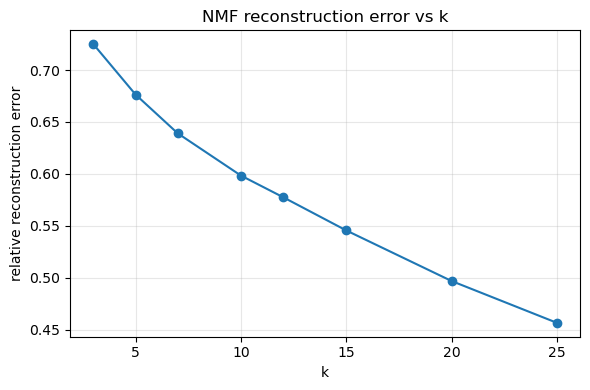

In [45]:
ks_nmf = [3, 5, 7, 10, 12, 15, 20, 25]
errs = []
for k_try in ks_nmf:
    nmf_k = NMF(n_components=k_try, init="nndsvd", random_state=RNG_SEED, max_iter=2000, tol=1e-4)
    W_k = nmf_k.fit_transform(P)
    err = np.linalg.norm(P - W_k @ nmf_k.components_, "fro") / np.linalg.norm(P, "fro")
    errs.append(err)
    print(f"k={k_try:2d}: relative error = {err:.3f}, iters = {nmf_k.n_iter_}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks_nmf, errs, marker="o")
ax.set(xlabel="k", ylabel="relative reconstruction error",
       title="NMF reconstruction error vs k")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()